In [ ]:
import numpy as np
import cupy as cp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

shape    = (3*400, 3*350)  # Nombre de píxels (Ny, Nz) a la pantalla.
#shape = (100,80)
y_range  = (-25, 25)     # Rang en el pla equatorial del forat negre.
z_range  = (-15, 15)     # Rang en la direcció de l'eix de rotació.
M          = 1        # Massa del forat negre.
view_angle = 0.25

# Definim alguns radis significatius
r_horizon = 2 * M
r_shadow  = 3 * cp.sqrt(3) * M
r_ISCO    = 6 * M
r_disk    = 18 #12

# Angle de 0 a 2pi, que serà útil per dibuixar cercles.
contour  = cp.linspace(0, 2 * cp.pi, 100)

In [ ]:
# per aefgir angle de la pantalla, s'ha e fer la rotacio de les posicions i le velocitats . canviar np amb cp pero al final fer cp.assnumpy pk matlpotlip  nomes funciona amb numpy

In [ ]:
def diverg(sin_th):
  files, columnes = np.where(np.isclose(sin_th, 0, atol=1e-2))

  for i, j in zip(files, columnes):
    sin_th [i,j] = sin_th[i,j] #+ 0.1
   # print(f"A la posició ({i}, {j})")

  return (sin_th)





In [ ]:
from re import X
# Definim les coordenades (t, x, y, z) inicials de l'eixam.
t_screen = 0.0
u_screen = 20.0
y_screen = cp.linspace(*y_range, shape[0])[:, None]
v_screen = cp.linspace(*z_range, shape[1])[None, :]

x_screen = cp.cos(view_angle) * u_screen - cp.sin(view_angle) * v_screen
z_screen = cp.cos(view_angle) * v_screen + cp.sin(view_angle) * u_screen

# Passem a coordenades esfèriques, per la mètrica de Schwarzschild.

t  = t_screen
r  = cp.sqrt(x_screen**2 + y_screen**2 + z_screen**2)
th = cp.arccos(z_screen / r + 1e-5)
ph = cp.arctan2(y_screen, x_screen)

#buscar on divideix per sin th pk pot ser 0, tot i això es soluciona augmentan el dl = 0.01

sin_th = cp.sin(th)
#sin_th = diverg(sin_th)

ddx = (sin_th * cp.cos(ph), cp.cos(th) * cp.cos(ph) / r, - cp.sin(ph) / (r * sin_th) )
ddz = (sin_th, - sin_th/r, 0)

dr_dl  = - ddx[0] * cp.cos(view_angle) - ddz[0] * cp.sin(view_angle)
dth_dl = - ddx[1] * cp.cos(view_angle) - ddz[1] * cp.sin(view_angle)
dph_dl = - ddx[2] * cp.cos(view_angle) - ddz[2] * cp.sin(view_angle)

# Ara normalitzem per tal que dt / dlambda = 1 i la 4-velocitat sigui nul·la.
norm2  = dr_dl**2 / (1 - 2 * M / r) + r**2 * (dth_dl**2 + sin_th**2 * dph_dl**2)
factor = cp.sqrt(norm2 / (1 - 2*M / r))

# Definim un eixam de fotons sobre la pantalla, amb els que farem el ray tracing.
swarm_init = cp.zeros(shape + (8,))

swarm_init[..., 0] = t
swarm_init[..., 1] = r
swarm_init[..., 2] = th
swarm_init[..., 3] = ph

swarm_init[..., 4] = 1
swarm_init[..., 5] = dr_dl  / factor
swarm_init[..., 6] = dth_dl / factor
swarm_init[..., 7] = dph_dl / factor

# Comprovem que la 4-velocitat és efectivament nul·la
cp.allclose(- (1 - 2 * M / r) * swarm_init[..., 4]**2 + swarm_init[..., 5]**2 / (1 - 2 * M / r) + \
            r**2 * (swarm_init[..., 6]**2 + cp.sin(th)**2 * swarm_init[..., 7]**2), 0)



array(True)

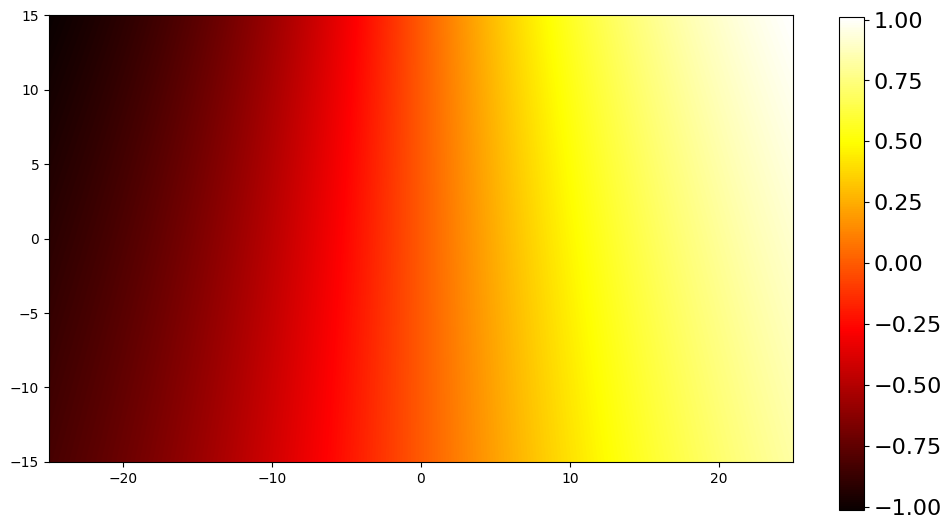

In [ ]:
# Aquí podem visualitzar les coordenades...
fig, ax = plt.subplots(1, 1, figsize = (12, 8))
plt.rc('font', size = 16)

ish = ax.imshow(cp.asnumpy(ph.T), cmap = 'hot', origin = 'lower', extent = y_range + z_range)
fig.colorbar(ish, ax=ax, location='right', anchor=(0, 0.3), shrink=0.8)


In [ ]:
# Càlcul dels símbols de Christoffel, que es retornen amb la forma (Ny, Nz).
# Important: cal tenir en compte que són simètrics en els dos índexs de baix.

def christoffel_cartesian(swarm, indices):
    _, x, y, z, _, _, _, _ = swarm.transpose(2, 0, 1)

    r = cp.sqrt(x**2 + y**2 + z**2)
    r2 = r**2
    r3 = r**3
    r5 = r**5
    f = 1 - 2*M / r        # lapse^2
    M2 = 2 * M

    # Índexs: 0=t, 1=x, 2=y, 3=z
    # xi[i] retorna la coordenada espacial i-èsima
    xi = [None, x, y, z]

    sigma = indices[0]   # índex superior
    mu    = indices[1]   # índex inferior 1
    nu    = indices[2]   # índex inferior 2

    # --- Γ^t_t i (i=x,y,z) ---
    # Γ^t_{t i} = M x^i / (r^3 f)
    if sigma == 0 and mu == 0 and nu in (1,2,3):
        gamma = M * xi[nu] / (r3 * f)
    elif sigma == 0 and nu == 0 and mu in (1,2,3):
        gamma = M * xi[mu] / (r3 * f)

    # --- Γ^i_tt  (i=x,y,z) ---
    # Γ^i_{tt} = M f x^i / r^3
    elif sigma in (1,2,3) and mu == 0 and nu == 0:
        gamma = M * f * xi[sigma] / r3

    # --- Γ^i_jk  (i,j,k espacials) ---
    # Γ^i_{jk} = (M/r^3) * [ x^i ( δ_jk / f  -  (1 + 1/f) x^j x^k / r^2 )
    #                        - (δ_ij x^k + δ_ik x^j) / f ]
    # ... que prové de derivar g_ij = -δ_ij/f - (1/f - f) x^i x^j / r^2
    elif sigma in (1,2,3) and mu in (1,2,3) and nu in (1,2,3):
        i, j, k = sigma, mu, nu
        d_ij = cp.ones_like(r) if i == j else cp.zeros_like(r)
        d_ik = cp.ones_like(r) if i == k else cp.zeros_like(r)
        d_jk = cp.ones_like(r) if j == k else cp.zeros_like(r)

        gamma = (M / r3) * (
            xi[i] * (d_jk / f - (1/f + 1) * xi[j] * xi[k] / r2) / f
            - (d_ij * xi[k] + d_ik * xi[j]) / f**2
        ) * (-1)   # signe: Γ = ½ g^{il}(∂_j g_lk + ∂_k g_lj - ∂_l g_jk)

    else:
        gamma = None

    return gamma



def christoffel(swarm, indices):
    # No necessitem la 4-velocitat per als Christoffels, la podem llençar
    _, r, th, ph, _, _, _, _  = swarm.transpose(2, 0, 1)

    sin_th = cp.sin(th)
    #sin_th = diverg(sin_th)

    if indices == (1, 0, 0):  # Γ^r_tt
        gamma = M * (r - 2 * M) / r**3

    elif (indices == (0, 0, 1)) or (indices == (0, 1, 0)):  # Γ^t_tr
        gamma = M / (r * (r - 2 * M))

    elif indices == (1, 1, 1):  # Γ^r_rr
        gamma = -M / (r * (r - 2 * M))

    elif indices == (1, 2, 2):  # Γ^r_θθ
        gamma = -(r - 2 * M)

    elif indices == (1, 3, 3):  # Γ^r_φφ
        gamma = -(r - 2 * M) * sin_th**2

    elif (indices == (2, 1, 2)) or (indices == (2, 2, 1)):  # Γ^θ_rθ
        gamma = 1 / r

    elif indices == (2, 3, 3):  # Γ^θ_φφ
        gamma = -sin_th * cp.cos(th)

    elif (indices == (3, 1, 3)) or (indices == (3, 3, 1)):  # Γ^φ_rφ
        gamma = 1 / r

    elif (indices == (3, 2, 3)) or (indices == (3, 3, 2)):  # Γ^φ_θφ
        gamma = cp.cos(th) / sin_th

    else:
        gamma = None

    return gamma


In [ ]:
# Funció que calculi la derivada de l'array swarm respecte
# al paràmetre afí a partir de l'equació geodèsica.

def geoeq(swarm):

    dswarm = cp.zeros_like(swarm)
    dswarm[..., :4] = swarm[..., 4:]

    for idx1 in range(4):
        for idx2 in range(4):
            for idx3 in range(idx2, 4):
                gamma = christoffel(swarm, (idx1, idx2, idx3))
                if gamma is not None:
                    # Sumem dues vegades els termes amb índexs diferents, per la simetria dels símbols de Christoffel.
                    dswarm[..., idx1 + 4] -= (2 - (idx2 == idx3)) * gamma * swarm[..., idx2 + 4] * swarm[..., idx3 + 4]

    dswarm[stopped_mask != 0] = 0.0
    return dswarm

# Funció que comprova la posició de cada fotó i actualitza
# les màscares que es faran servir en l'evolució.

def update_masks(swarm, new_swarm):

    _, r, th, _, _, _, _, _    = swarm.transpose(2, 0, 1)
    _, _, n_th, _, _, _, _, _  = new_swarm.transpose(2, 0, 1)

    fell_into_horizon     = (r <= 1.1 * r_horizon)
    went_too_far          = (r > 30)
    crossed_the_equator   = (cp.cos(th) * cp.cos(n_th) < 0)
    hit_the_disk          = crossed_the_equator & (r > r_ISCO) & (r < r_disk)
    canvas[hit_the_disk] += r[hit_the_disk]

    stopped_mask[fell_into_horizon | went_too_far] = True

# Integrador Runge-Kutta 4 que aprofita la funció anterior per
# evolucionar l'array swarm un pas de paràmetre afí dlam.

def RK4(lam, swarm):
    k1 = geoeq(swarm)
    k2 = geoeq(swarm + 0.5 * k1 * dlam)
    k3 = geoeq(swarm + 0.5 * k2 * dlam)
    k4 = geoeq(swarm + k3 * dlam)

    new_lam   = lam + dlam
    new_swarm = swarm + dlam * (k1 + 2*k2 + 2*k3 + k4) / 6

    update_masks(swarm, new_swarm)

    return new_lam, new_swarm

# Funció que converteix les coordenades de Schwarzschild en cartesianes
# per tal de poder dibuixar les trajectòries en matplotlib.

def toCartesian(swarm):
    _, r, th, ph, _, _, _, _  = swarm.transpose(2, 0, 1)
    x = r * cp.sin(th) * cp.cos(ph)
    y = r * cp.sin(th) * cp.sin(ph)
    z = r * cp.cos(th)
    return x, y, z

In [ ]:
# Posem el paràmetre afí lam = 0 per a tots els fotons.
lam, dlam = 0, 0.05
steps = 1000

# Inicialitzem l'eixam de fotons i els arrays on guardar-lo.
swarm = swarm_init
# xlist, _, zlist = toCartesian(swarm)

# Inicialitzem les màscares
stopped_mask      = cp.zeros_like(r, dtype = bool)
canvas            = cp.zeros_like(r)

# xlist = cp.zeros((steps,) + shape, dtype=cp.float64)
# zlist = cp.zeros((steps,) + shape, dtype=cp.float64)

for it in tqdm(range(steps)):
    lam, swarm = RK4(lam, swarm)
    # x, _, z    = toCartesian(swarm)
    # xlist[it, :, :] = x
    # zlist[it, :, :] = z

print(f'Paràmetre afí al final de la integració: {lam:.2f}')




  0%|          | 0/1000 [00:00<?, ?it/s]

Paràmetre afí al final de la integració: 50.00


In [ ]:
'''
fell   = cp.asnumpy(fell_into_horizon[0, :])
hit    = cp.asnumpy(hit_the_disk[0, :])
z_inicial_positiva = cp.asnumpy(zlist[0, :] > 0)

x_plot = xlist.get()
z_plot = zlist.get()

pas = 10

# Creem les màscares combinades
fell_pos = fell & z_inicial_positiva
hit_pos  = hit  & z_inicial_positiva
vives_pos = (~fell) & z_inicial_positiva

fig, ax = plt.subplots(1, 1, figsize = (9, 6));
plt.rc('font', size = 16)

# Ara plotegem igual que abans però amb les noves màscares
ax.plot(x_plot[:, fell_pos][:, ::pas], z_plot[:, fell_pos][:, ::pas], color='black', lw=0.5)
ax.plot(x_plot[:, vives_pos][:, ::pas], z_plot[:, vives_pos][:, ::pas], color='blue', lw=0.5)
ax.plot(x_plot[:, hit_pos][:, ::pas], z_plot[:, hit_pos][:, ::pas], color='orange', lw=1)

contour_plot = cp.asnumpy(contour)

ax.plot([-r_disk, -r_ISCO, np.nan, r_ISCO, r_disk], np.zeros(5),  color = 'red', lw = 3)
ax.fill(r_horizon * np.cos(contour_plot), r_horizon * np.sin(contour_plot), color = 'black')
ax.plot(r_ISCO * np.cos(contour_plot), r_ISCO * np.sin(contour_plot), ls = ':', color = 'black')

ax.text(8, 3, 'Shadow')
ax.text(-10, -2, 'Disk')
ax.text(5.5, -4, 'ISCO')
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim(-15,15)
ax.set_ylim(-10,10)
ax.grid()

'''

"\nfell   = cp.asnumpy(fell_into_horizon[0, :])\nhit    = cp.asnumpy(hit_the_disk[0, :])\nz_inicial_positiva = cp.asnumpy(zlist[0, :] > 0)\n\nx_plot = xlist.get()\nz_plot = zlist.get()\n\npas = 10\n\n# Creem les màscares combinades\nfell_pos = fell & z_inicial_positiva\nhit_pos  = hit  & z_inicial_positiva\nvives_pos = (~fell) & z_inicial_positiva\n\nfig, ax = plt.subplots(1, 1, figsize = (9, 6));\nplt.rc('font', size = 16)\n\n# Ara plotegem igual que abans però amb les noves màscares\nax.plot(x_plot[:, fell_pos][:, ::pas], z_plot[:, fell_pos][:, ::pas], color='black', lw=0.5)\nax.plot(x_plot[:, vives_pos][:, ::pas], z_plot[:, vives_pos][:, ::pas], color='blue', lw=0.5)\nax.plot(x_plot[:, hit_pos][:, ::pas], z_plot[:, hit_pos][:, ::pas], color='orange', lw=1)\n\ncontour_plot = cp.asnumpy(contour)\n\nax.plot([-r_disk, -r_ISCO, np.nan, r_ISCO, r_disk], np.zeros(5),  color = 'red', lw = 3)\nax.fill(r_horizon * np.cos(contour_plot), r_horizon * np.sin(contour_plot), color = 'black')\nax.pl

In [2]:
'''
stopped_mask[fell_into_horizon] = 1
stopped_mask[ went_too_far] = 2
stopped_mask[ hit_the_disk] = 3

'''

# --- Plot 3D ---
from matplotlib.colors import ListedColormap
colors_estat = ['blue','black', 'blue', 'orange']
cmap= ListedColormap(colors_estat)

#mask_plot = stopped_mask.get()
fig, ax = plt.subplots(1, 1, figsize = (9, 6));
plt.rc('font', size = 16)
plt.imshow(cp.asnumpy(canvas).T, cmap='hot', interpolation='none', origin = 'lower', extent = y_range + z_range)
plt.title(f"view angle = {view_angle:.2f} rad")
#ax.set_xlim(-15,15)
#ax.set_ylim(-6,6)
plt.tight_layout()
#plt.plot(2 * M * np.cos(contour_plot), 2 * M * np.sin(contour_plot), '--k', color='green')

plt.show()
plt.savefig(f"BH_{view_angle:.2f}_error")

NameError: name 'plt' is not defined